In [3]:
import pandas as pd

df = pd.read_csv("data/monthly_births_2024.csv")

print(df)
print("\nShape:", df.shape)

    month  births month_name
0       1  297798    January
1       2  283858   February
2       3  298760      March
3       4  290212      April
4       5  303925        May
5       6  293893       June
6       7  319953       July
7       8  326595     August
8       9  309136  September
9      10  314890    October
10     11  292568   November
11     12  306848   December

Shape: (12, 3)


In [8]:
%pip install --upgrade --force-reinstall scikit-learn

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.5.3 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.9.1 which is incompatible.



  Using cached numpy-2.5.3-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.18.1-cp313-cp313-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -----------------------------------

In [14]:
conda create -n birthforecast python=3.12 -y


Note: you may need to restart the kernel to use updated packages.



CondaToSNonInteractiveError: Terms of Service have not been accepted for the following channels. Please accept or remove them before proceeding:
    • https://repo.anaconda.com/pkgs/main
    • https://repo.anaconda.com/pkgs/r
    • https://repo.anaconda.com/pkgs/msys2

To accept a channel's Terms of Service, run the following and replace `CHANNEL` with the channel name/URL:
    ‣ conda tos accept --override-channels --channel CHANNEL

To remove channels with rejected Terms of Service, run the following and replace `CHANNEL` with the channel name/URL:
    ‣ conda config --remove channels CHANNEL



In [15]:
conda activate birthforecast


Note: you may need to restart the kernel to use updated packages.



CondaError: Run 'conda init' before 'conda activate'



In [16]:
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels prophet xgboost joblib streamlit

  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.4.1-py3-none-win_amd64.whl (48.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
print("NumPy:", np.__version__)

import sklearn
print("Scikit-learn:", sklearn.__version__)

from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Everything is working!")

NumPy: 2.2.6
Scikit-learn: 1.7.1
Everything is working!


In [4]:
import pandas as pd

df = pd.read_csv("data/monthly_births_2024.csv")

print(df)
print("\nShape:", df.shape)

    month  births month_name
0       1  297798    January
1       2  283858   February
2       3  298760      March
3       4  290212      April
4       5  303925        May
5       6  293893       June
6       7  319953       July
7       8  326595     August
8       9  309136  September
9      10  314890    October
10     11  292568   November
11     12  306848   December

Shape: (12, 3)


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Prepare dates
df["month"] = df["month"].astype(str).str.zfill(2)

df["ds"] = pd.to_datetime(
    "2024-" + df["month"] + "-01"
)

# Actual values
actual = df["births"].values

# Train Prophet again for evaluation
from prophet import Prophet

forecast_df = df[["ds", "births"]].rename(
    columns={"births": "y"}
)

model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(forecast_df)

# Predict the same historical dates
predictions = model.predict(forecast_df[["ds"]])

predicted = predictions["yhat"].values

print("Actual values:", actual)
print("Predicted values:", predicted)

Importing plotly failed. Interactive plots will not work.
17:58:02 - cmdstanpy - INFO - Chain [1] start processing
17:58:02 - cmdstanpy - INFO - Chain [1] done processing


Actual values: [297798 283858 298760 290212 303925 293893 319953 326595 309136 314890
 292568 306848]
Predicted values: [294018.128535   295722.09680628 297316.13164929 299020.099851
 300669.10125663 302373.06928157 304019.11515501 305719.19489138
 307410.18762103 309046.61707239 310737.59417214 312374.0236235 ]


In [6]:
mae = mean_absolute_error(actual, predicted)

rmse = np.sqrt(mean_squared_error(actual, predicted))

mape = np.mean(
    np.abs((actual - predicted) / actual)
) * 100

print("Model Evaluation Results")
print("------------------------")
print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("MAPE :", round(mape, 2), "%")

Model Evaluation Results
------------------------
MAE  : 8808.87
RMSE : 10819.38
MAPE : 2.89 %


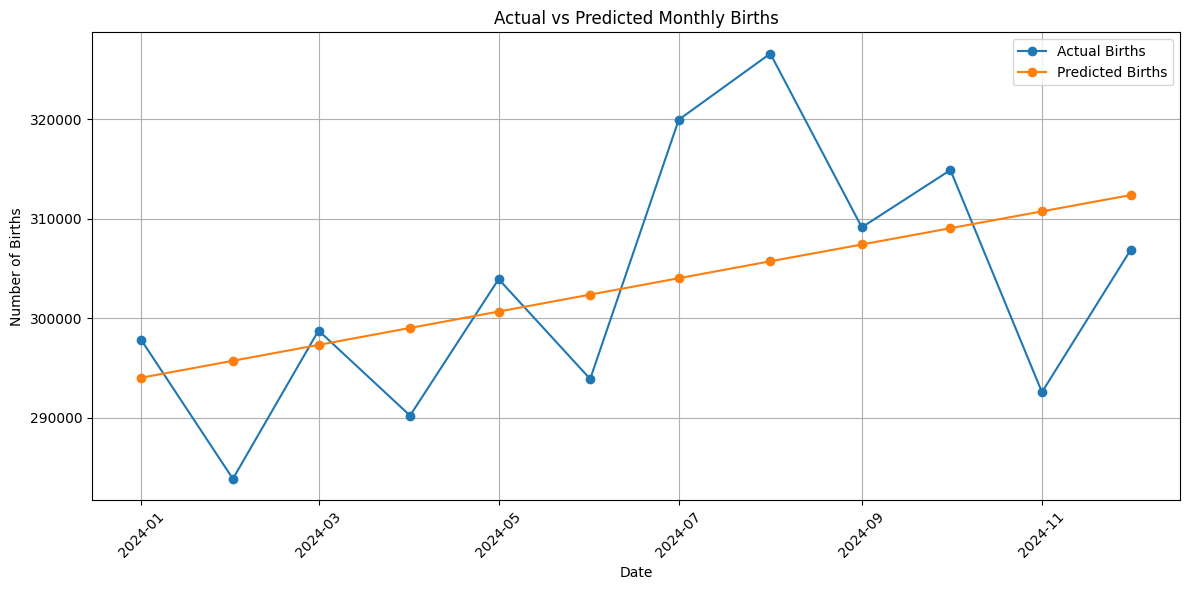

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    df["ds"],
    actual,
    marker="o",
    label="Actual Births"
)

plt.plot(
    df["ds"],
    predicted,
    marker="o",
    label="Predicted Births"
)

plt.title("Actual vs Predicted Monthly Births")
plt.xlabel("Date")
plt.ylabel("Number of Births")

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [8]:
evaluation_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE"],
    "Value": [mae, rmse, mape]
})

evaluation_results.to_csv(
    "data/evaluation_results.csv",
    index=False
)

print("Evaluation results saved successfully!")
print(evaluation_results)

Evaluation results saved successfully!
  Metric         Value
0    MAE   8808.867296
1   RMSE  10819.375440
2   MAPE      2.893432


In [9]:
import pandas as pd

# Load the final forecast created earlier
forecast_table = pd.read_csv(
    "data/final_birth_forecast.csv"
)

# Convert date column
forecast_table["ds"] = pd.to_datetime(
    forecast_table["ds"]
)

# Healthcare resource planning assumptions
beds_per_100_births = 10
nurses_per_100_births = 5

# Calculate estimated requirements
resource_plan = forecast_table.copy()

resource_plan["Estimated_Beds"] = (
    resource_plan["Predicted_Births"]
    / 100
    * beds_per_100_births
).round().astype(int)

resource_plan["Estimated_Nurses"] = (
    resource_plan["Predicted_Births"]
    / 100
    * nurses_per_100_births
).round().astype(int)

print(resource_plan[
    [
        "ds",
        "Predicted_Births",
        "Estimated_Beds",
        "Estimated_Nurses"
    ]
])

          ds  Predicted_Births  Estimated_Beds  Estimated_Nurses
0 2025-01-01            314065           31406             15703
1 2025-02-01            315756           31576             15788
2 2025-03-01            317283           31728             15864
3 2025-04-01            318974           31897             15949
4 2025-05-01            320611           32061             16031
5 2025-06-01            322302           32230             16115


In [10]:
resource_plan.to_csv(
    "data/healthcare_resource_plan.csv",
    index=False
)

print("Healthcare resource plan saved successfully!")

Healthcare resource plan saved successfully!


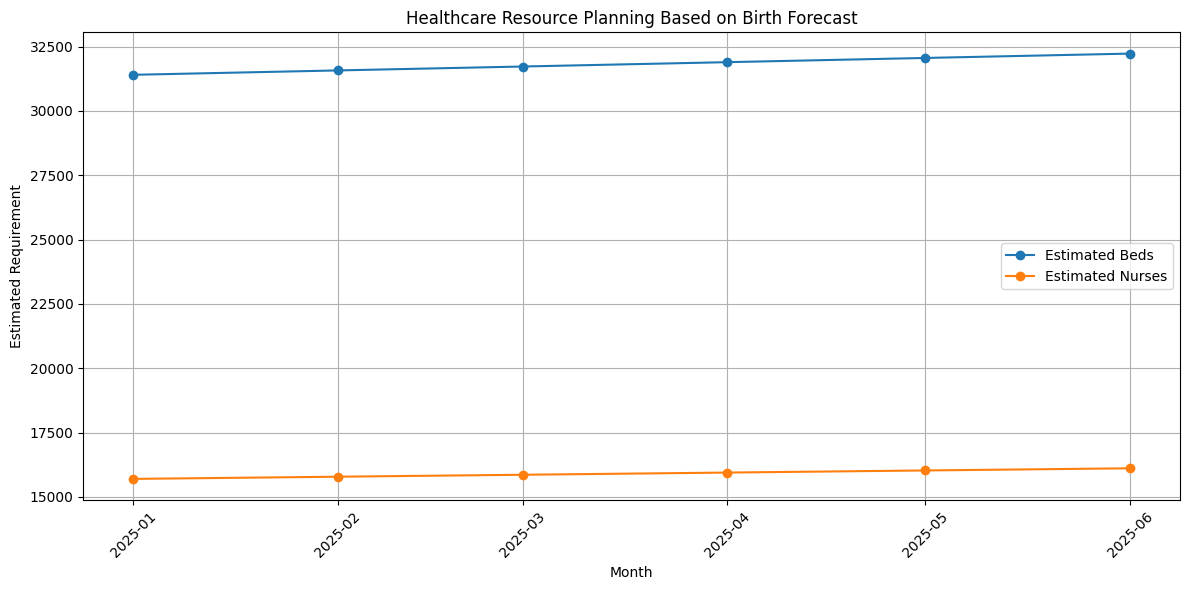

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    resource_plan["ds"],
    resource_plan["Estimated_Beds"],
    marker="o",
    label="Estimated Beds"
)

plt.plot(
    resource_plan["ds"],
    resource_plan["Estimated_Nurses"],
    marker="o",
    label="Estimated Nurses"
)

plt.title("Healthcare Resource Planning Based on Birth Forecast")
plt.xlabel("Month")
plt.ylabel("Estimated Requirement")

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
summary = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "MAPE"
    ],
    "Value": [
        mae,
        rmse,
        mape
    ]
})

summary.to_csv(
    "data/project_evaluation_summary.csv",
    index=False
)

print("Project evaluation summary saved successfully!")
print(summary)

Project evaluation summary saved successfully!
  Metric         Value
0    MAE   8808.867296
1   RMSE  10819.375440
2   MAPE      2.893432
